# Variance reduction techniques
### Control Variates and Antithetic Variates

In [1]:
#init
%load_ext autoreload
%autoreload 2

import lib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import time




# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.05             # Risk-free rate
sigma = 0.3          # Volatility
gamma = 1.2          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps (daily)

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)

# Set simulation parameters
N = 2**13            # Number of paths (power of 2 for QMC)
batches = 32          # Number of batches/scrambles 32

out_dir = 'Graphs'
dir_Tables = 'Tables'
os.makedirs(out_dir, exist_ok=True)
os.makedirs(dir_Tables, exist_ok=True)

N=16384, mean(geometric)=7.650919, mean(arithmetic)=18.288955, corr=0.921075, beta_opt=3.257404, CV_mean=17.865903


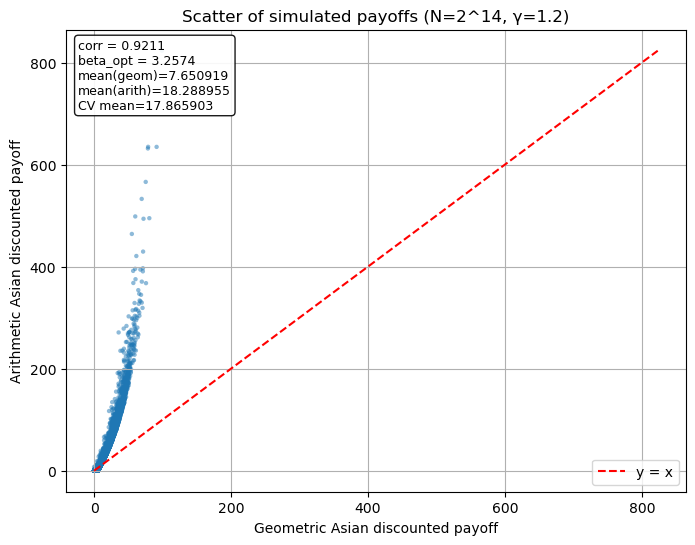

In [2]:


sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)

# Scatterplot of geometric vs arithmetic Asian discounted payoffs
# We'll draw a moderate number of pseudo-random paths and compute both payoffs
exp=14
N_scatter = 2**exp  # 2048 (power-of-two convenient if switching to QMC)
# draw pseudo-random standard normals (N_scatter x M)
Z_scatter = sim.draw_pseudo_random_numbers(sim.base_seed, N_scatter, sim.M)
# Alternative QMC example (uncomment to use; requires N_scatter to be power of two)
#Z_scatter = sim.draw_quasi_random_numbers_bb(sim.base_seed + 888, N_scatter, sim.M)
# arithmetic discounted payoffs (vector)
arith_payoffs = sim.price_asian_option_from_Z_raw(Z_scatter, euler=False)
# geometric discounted payoffs (vector) computed from same Z
geom_payoffs = sim.sim_GBM_paths(N_scatter, Z_scatter)
# Quick summary statistics and optimal-beta control variate
import numpy as np
X = arith_payoffs
Y = geom_payoffs
Xc = X - X.mean()
Yc = Y - Y.mean()
den = (Yc**2).sum()
beta_opt = 0.0 if den == 0 else (Xc*Yc).sum() / den
mu_Y = sim.geometric_asian_closed_form()
adj = X + beta_opt * (mu_Y - Y)
adj_mean = adj.mean()
corr = np.corrcoef(Y, X)[0,1]
mean_g = Y.mean()
mean_a = X.mean()
print(f"N={N_scatter}, mean(geometric)={mean_g:.6f}, mean(arithmetic)={mean_a:.6f}, corr={corr:.6f}, beta_opt={beta_opt:.6f}, CV_mean={adj_mean:.6f}")
# Scatter plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(geom_payoffs, arith_payoffs, s=10, alpha=0.5, edgecolors='none')
lims = [min(geom_payoffs.min(), arith_payoffs.min()), max(geom_payoffs.max(), arith_payoffs.max())]
ax.plot(lims, lims, color='red', linestyle='--', label='y = x')
ax.set_xlabel('Geometric Asian discounted payoff')
ax.set_ylabel('Arithmetic Asian discounted payoff')
ax.set_title(f'Scatter of simulated payoffs (N=2^{exp}, γ={gamma})')
ax.legend()
ax.grid(True)
# add annotation with correlation, optimal beta and CV-adjusted mean
ann_text = f'corr = {corr:.4f}\nbeta_opt = {beta_opt:.4f}\nmean(geom)={mean_g:.6f}\nmean(arith)={mean_a:.6f}\nCV mean={adj_mean:.6f}'
ax.text(0.02, 0.98, ann_text, transform=ax.transAxes, fontsize=9, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
plt.savefig(os.path.join(out_dir, 'corr.png'), dpi=150)
plt.show()

In [3]:
import pandas as pd
import numpy as np
import time
gammas = [g for g in np.arange(0.7, 1.45, 0.01)]  # from 0.7 to 1.4 step 0.01
rows = []
# Use a moderate sample size for the table to keep runtime reasonable
N_table = 2**14  # 131072
batches_table = 32

for g in gammas:
    sim_local = lib.MonteCarloSimulation(S0, K, r, sigma, g, T, M)
    # draw one pooled sample to compute sample correlation between geom and arith payoffs
    Z = sim_local.draw_pseudo_random_numbers(sim_local.base_seed , N_table, sim_local.M)
    X = sim_local.price_asian_option_from_Z_raw(Z, euler=False)  # arithmetic discounted payoffs (vector)
    Y = sim_local.sim_GBM_paths(N_table, Z)  # geometric discounted payoffs (vector)
    corr = float(np.corrcoef(Y, X)[0,1])
    # estimate SE using batch replicates (plain MC and MC+CV) and measure time
    t0 = time.perf_counter()
    _, se_plain, _, _ = sim_local.mc_with_batches(N_table, batches_table, euler=False, CV=False)
    t_plain = time.perf_counter() - t0
    t0 = time.perf_counter()
    _, se_cv, _, _ = sim_local.mc_with_batches(N_table, batches_table, euler=False, CV=True)
    t_cv = time.perf_counter() - t0
    vrf = (se_plain / se_cv)**2 if se_cv > 0 else np.nan
    time_ratio = t_cv / t_plain if t_plain > 0 else np.nan
    #rows.append({'gamma': g, 'corr': corr, 'SE_plain': se_plain, 'SE_CV': se_cv, 'VRF': vrf, 'Time_plain': t_plain, 'Time_CV': t_cv, 'Time_ratio': time_ratio})
    rows.append({'gamma': g, 'corr': corr, 'SE_plain': se_plain, 'SE_CV': se_cv, 'VRF': vrf, 'Time_ratio': time_ratio})
df = pd.DataFrame(rows)
# format for display similar to the example
df_display = df.copy()
df_display['gamma'] = df_display['gamma'].round(2)
df_display['corr'] = df_display['corr'].round(2)
df_display['SE_plain'] = df_display['SE_plain'].round(3)
df_display['SE_CV'] = df_display['SE_CV'].round(3)
df_display['VRF'] = df_display['VRF'].apply(lambda x: f"{x:.1f}x" if not np.isnan(x) else 'nan')
#df_display['Time_plain'] = df_display['Time_plain'].round(2)
#df_display['Time_CV'] = df_display['Time_CV'].round(2)
df_display['Time_ratio'] = df_display['Time_ratio'].round(2)
#df_display = df_display.rename(columns={'gamma':'γ', 'corr':'Corr(geom, arith)', 'SE_plain':'SE (plain MC)', 'SE_CV':'SE (MC+CV)', 'VRF':'VRF', 'Time_plain':'Time (plain s)', 'Time_CV':'Time (MC+CV s)', 'Time_ratio':'Time ratio'})
df_display = df_display.rename(columns={'gamma':'$\gamma$', 'corr':'Corr(geom, arith)', 'SE_plain':'SE (plain MC)', 'SE_CV':'SE (MC+CV)', 'VRF':'VRF', 'Time_ratio':'Time ratio'})
print(f'Using N={N_table}, batches={batches_table}')
latex_path = os.path.join(dir_Tables, 'corrMC.tex')
#df_display.to_latex(buf=latex_path, index=False, float_format="%.3f")
# write LaTeX with column-specific formatting so decimals match printed table
formatters = {
    '$\gamma$': lambda x: f"{x:.2f}",
    'Corr(geom, arith)': lambda x: f"{x:.2f}",
    'SE (plain MC)': lambda x: f"{x:.3f}",
    'SE (MC+CV)': lambda x: f"{x:.3f}",
    'VRF': lambda x: x if isinstance(x, str) else f"{x:.1f}x",
    'Time ratio': lambda x: f"{x:.2f}"
}
df_display.to_latex(buf=latex_path, index=False, formatters=formatters, escape=False)
display(df_display)

/Users/nicklasjensen/Desktop/Økonomi/Monte carlo/code/MonteCarlo-in-finance/lib.py:301: RuntimeWarning: overflow encountered in exp
  S_n = np.exp(logS_n)
/Users/nicklasjensen/Desktop/Økonomi/Monte carlo/code/MonteCarlo-in-finance/lib.py:320: RuntimeWarning: invalid value encountered in add
  logS_next = logS_n + drift + diffusion + correction
/Users/nicklasjensen/Desktop/Økonomi/Monte carlo/code/MonteCarlo-in-finance/lib.py:324: RuntimeWarning: overflow encountered in exp
  return np.exp(logS)
/Users/nicklasjensen/Desktop/Økonomi/Monte carlo/code/MonteCarlo-in-finance/lib.py:415: RuntimeWarning: invalid value encountered in subtract
  Xc, Yc = X - Xbar, Y - Ybar
/Users/nicklasjensen/anaconda3/envs/mc-py310/lib/python3.10/site-packages/numpy/core/_methods.py:181: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Using N=16384, batches=32


,$\gamma$,"Corr(geom, arith)",SE (plain MC),SE (MC+CV),VRF,Time ratio
0,0.70,0.96,4.000000e-03,1.000000e-03,14.1x,1.04
1,0.71,0.96,5.000000e-03,1.000000e-03,15.1x,1.08
2,0.72,0.97,5.000000e-03,1.000000e-03,16.1x,1.07
3,0.73,0.97,5.000000e-03,1.000000e-03,17.2x,1.08
4,0.74,0.97,5.000000e-03,1.000000e-03,18.3x,1.07
...,...,...,...,...,...,...
70,1.40,0.29,1.401903e+09,1.296808e+09,1.2x,1.06
71,1.41,0.23,1.557963e+14,1.444583e+14,1.2x,1.07
72,1.42,0.19,4.350424e+136,4.131291e+136,1.1x,1.08
73,1.43,0.18,NaN,NaN,nan,1.05


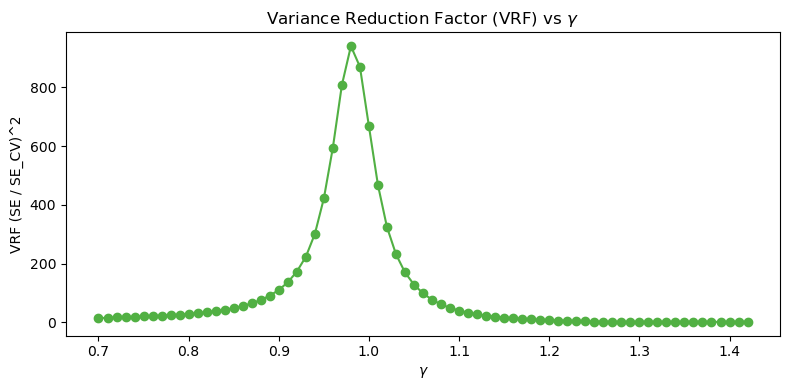

In [4]:

# Expect df from the previous cell (numeric VRF and optional Time_ratio)
if 'df' not in globals():
    raise RuntimeError('DataFrame `df` not found in notebook scope. Run the summary table cell first.')
# intercept Axes.set_xticks to limit number of tick positions (avoid overcrowding)

# keep full data for plotting
x = df['gamma']
y_vrf = df['VRF']
y_vrf = df['VRF']
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(x, y_vrf, marker='o', color='#51b043', label='VRF')
ax1.set_xlabel('$\gamma$')
ax1.set_ylabel('VRF (SE / SE_CV)^2')
ax1.tick_params(axis='y')

# secondary axis for time ratio if present
#if 'Time_ratio' in df.columns:
#    ax2 = ax1.twinx()
#    ax2.plot(x, df['Time_ratio'], marker='s', linestyle='--', color='C1', label='Time ratio')
#    ax2.set_ylabel('Time ratio (MC+CV / plain)', color='C1')
#    ax2.set_ylim(0,2)
#    ax2.tick_params(axis='y', labelcolor='C1')
# title and legend
plt.title('Variance Reduction Factor (VRF) vs $\gamma$')
# combine legends if both axes used
#lines, labels = ax1.get_legend_handles_labels()
#if 'ax2' in locals():
#    lines2, labels2 = ax2.get_legend_handles_labels()
#    lines += lines2; labels += labels2
#    ax1.legend(lines, labels, loc='upper left')
#else:
#    ax1.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'VRF_vs_gamma.png'), dpi=150)
plt.show()



In [5]:
# diagnostic for a specific gamma
g = 1.35   # pick a gamma that produced nan
sim_local = lib.MonteCarloSimulation(S0, K, r, sigma, g, T, M)
Ndiag = 4096
Z = sim_local.draw_pseudo_random_numbers(sim_local.base_seed, Ndiag, sim_local.M)

# compute raw payoffs
X = sim_local.price_asian_option_from_Z_raw(Z, euler=False)    # CEV arithmetic payoffs (vector)
Y = sim_local.sim_GBM_paths(Ndiag, Z)                          # geometric payoffs (vector)

import numpy as np
def quick_stats(arr, name):
    arr = np.asarray(arr, dtype=float)
    print(name, "size", arr.size,
          "finite:", np.isfinite(arr).sum(),
          "nan:", np.isnan(arr).sum(),
          "inf:", np.isinf(arr).sum(),
          "zeros:", np.sum(arr==0.0),
          "min/max:", np.nanmin(arr), np.nanmax(arr))

quick_stats(X, "CEV arithmetic X")
quick_stats(Y, "GBM geometric Y")

# check replicate/se behavior (small number of batches/scrambles)
batches = 8
est_mc = sim_local.mc_with_batches(Ndiag, batches, euler=False, CV=False)
est_cv = sim_local.mc_with_batches(Ndiag, batches, euler=False, CV=True)
print("MC replicate output:", est_mc)
print("MC+CV replicate output:", est_cv)

CEV arithmetic X size 4096 finite: 4096 nan: 0 inf: 0 zeros: 3095 min/max: 0.0 2097.2908084401242
GBM geometric Y size 4096 finite: 4096 nan: 0 inf: 0 zeros: 2074 min/max: 0.0 91.32611267381161
MC replicate output: (23.44394536375251, 0.4142341996298207, (22.4644, 24.4235), 1.3727197771436654)
MC+CV replicate output: (23.968806527767953, 0.42522270407271934, (22.9633, 24.9743), 1.4465147844713235)


### Antithetic

In [6]:
test_cases= range(8,19)# 256 .. 524.288 insert 20
N_values = [2**k for k in test_cases]  
N_values_labels = [f"${2}^{{{k}}}$" for k in  test_cases]
prices_mc, errors_mc, cis_mc, times_mc = sim.plot_convergence(N_values,method='mc', batches=batches)
prices_qmc, errors_qmc, cis_qmc, times_qmc = sim.plot_convergence(N_values,method='mc + antithetic', batches=batches)

# Format CI data
def fmt_ci(ci):
    for i in range(len(ci)):
        low, high = ci[i]
        ci[i] = (float(low), float(high))
    return ci

cis_mc = fmt_ci(cis_mc)
cis_qmc = fmt_ci(cis_qmc)

# Handle CI input for matplotlib errorbar
def ci_to_yerr(prices, cis):
    """Convert CI information to yerr accepted by plt.errorbar."""
    prices = np.asarray(prices, dtype=float)
    cis_arr = np.asarray(cis)
    if cis_arr.ndim == 2 and cis_arr.shape[1] == 2:
        lows = cis_arr[:, 0].astype(float)
        highs = cis_arr[:, 1].astype(float)
        lower_err = prices - lows
        upper_err = highs - prices
    return np.vstack([lower_err, upper_err])
# Build yerr arrays robustly
yerr_mc = ci_to_yerr(np.array(prices_mc), cis_mc)
yerr_qmc = ci_to_yerr(np.array(prices_qmc), cis_qmc)


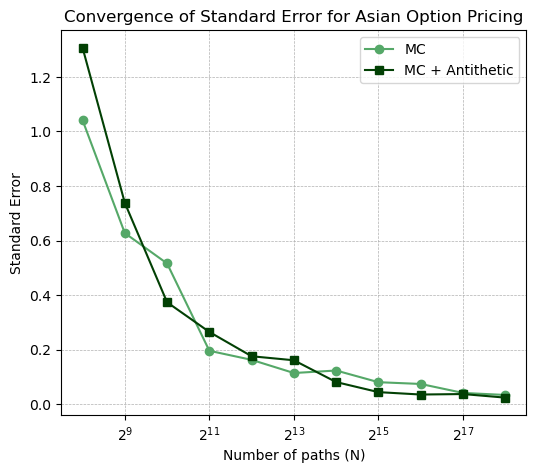

In [7]:
plt.figure(figsize=(6,5))
plt.plot(N_values, errors_mc, marker='o', label='MC', color='#55A868')
plt.plot(N_values, errors_qmc, marker='s', label='MC + Antithetic', color="#024004")
plt.xscale('log', base=2)
#plt.yscale('log')
#plt.xticks(N_values, N_values_labels)
plt.xlabel('Number of paths (N)')
plt.ylabel('Standard Error')
plt.title('Convergence of Standard Error for Asian Option Pricing')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.savefig(os.path.join(out_dir, 'std_error_convergence_MC_anti.png'), dpi=150)
plt.show()

In [8]:
# Create a dataframe comparing CMC vs RQMC across the tested N_values
# Ensure the 'N' array has the same length as the result arrays to avoid ValueError
N_values_labels = [f"${2}^{{{k}}}$" for k in  test_cases]
expected_len = len(prices_mc)
df_compare = None
# If an existing df_compare already matches the result arrays, reuse it.
# Otherwise, construct a new df_compare using an appropriate N list.
if 'df_compare' in globals() and isinstance(df_compare, pd.DataFrame) and len(df_compare) == expected_len:
    # reuse existing df_compare (assumed to match prices_*/errors_*/times_*)
    pass
else:
    # Determine N_list that matches the length of the result arrays.
    if 'N_values' in globals() and len(N_values) == expected_len:
        N_list = N_values
    else:
        # Fallback: reconstruct a powers-of-two sequence starting at 2**8
        N_list = [2**k for k in range(8, 8 + expected_len)]

    df_compare = pd.DataFrame({
        'N': N_values_labels,
        'Price': np.array(prices_mc).round(4),
        'SE': np.array(errors_mc).round(4),
        'Time': np.array(times_mc).round(4),
        'Price$_{Antithetic}$': np.array(prices_qmc).round(4),
        'SE$_{Antithetic}$': np.array(errors_qmc).round(4),
        'Time$_{Antithetic}$': np.array(times_qmc).round(4),
    })

    # Useful metrics
    #df_compare['se_ratio_mc_to_qmc'] = df_compare['se$_{mc}$'] / df_compare['se$_{qmc}$']  # how many times SE_mc is bigger than SE_qmc
    df_compare['VRF'] = ((df_compare['SE'] / df_compare['SE$_{Antithetic}$'])**2).round(4)  # Variance Reduction Factor
    df_compare['Time ratio'] = (df_compare['Time$_{Antithetic}$'] / df_compare['Time']).round(4)  # how many times time_mc is bigger than time_qmc

# Display and save for later reference
df_compare.drop(columns=['se_ratio_mc_to_qmc'], errors='ignore', inplace=True)
df_display=df_compare[['N', 'Price', 'SE', 'Price$_{Antithetic}$', 'SE$_{Antithetic}$', 'VRF', 'Time ratio']]

latex_path = os.path.join(dir_Tables, 'CMC_vs_Anti_comparison.tex')
df_display.to_latex(buf=latex_path, index=False, float_format="%.4f")
df_display


,N,Price,SE,Price$_{Antithetic}$,SE$_{Antithetic}$,VRF,Time ratio
0,$2^{8}$,16.8178,1.0414,18.2741,1.3070,0.6349,0.9669
1,$2^{9}$,17.5001,0.6274,17.8368,0.7382,0.7223,0.8906
2,$2^{10}$,17.6843,0.5161,17.9625,0.3739,1.9053,0.8599
3,$2^{11}$,17.6864,0.1962,18.0806,0.2651,0.5477,0.8524
4,$2^{12}$,17.6263,0.1629,17.7911,0.1761,0.8557,0.9058
5,$2^{13}$,17.9305,0.1147,17.8441,0.1614,0.5050,0.8837
6,$2^{14}$,17.8538,0.1238,17.9769,0.0815,2.3074,0.9337
7,$2^{15}$,17.8782,0.0811,17.9330,0.0446,3.3065,0.9374
8,$2^{16}$,17.9237,0.0746,17.9091,0.0358,4.3422,0.9194
9,$2^{17}$,17.8972,0.0417,17.9283,0.0376,1.2300,0.9021


# RQMC

In [9]:
import pandas as pd
import numpy as np
import time
gammas = [g for g in np.arange(0.7, 1.4, 0.01)]
rows = []
# Use a moderate sample size for the table to keep runtime reasonable
N_table = 2**14  # 
batches_table = 32
for g in gammas:
    sim_local = lib.MonteCarloSimulation(S0, K, r, sigma, g, T, M)
    # draw one pooled sample to compute sample correlation between geom and arith payoffs
    Z = sim_local.draw_quasi_random_numbers_bb(sim_local.base_seed , N_table, sim_local.M)
    X = sim_local.price_asian_option_from_Z_raw(Z, euler=False)  # arithmetic discounted payoffs (vector)
    Y = sim_local.sim_GBM_paths(N_table, Z)  # geometric discounted payoffs (vector)
    corr = float(np.corrcoef(Y, X)[0,1])
    # estimate SE using batch replicates (plain MC and MC+CV) and measure time
    t0 = time.perf_counter()
    _, se_plain, _, _ = sim_local.rqmc_with_scrambles(N_table, batches_table, euler=False, CV=False)
    t_plain = time.perf_counter() - t0
    t0 = time.perf_counter()
    _, se_cv, _, _ = sim_local.rqmc_with_scrambles(N_table, batches_table, euler=False, CV=True)
    t_cv = time.perf_counter() - t0
    vrf = (se_plain / se_cv)**2 if se_cv > 0 else np.nan
    time_ratio = t_cv / t_plain if t_plain > 0 else np.nan
    #rows.append({'gamma': g, 'corr': corr, 'SE_plain': se_plain, 'SE_CV': se_cv, 'VRF': vrf, 'Time_plain': t_plain, 'Time_CV': t_cv, 'Time_ratio': time_ratio})
    rows.append({'gamma': g, 'corr': corr, 'SE_plain': se_plain, 'SE_CV': se_cv, 'VRF': vrf, 'Time_ratio': time_ratio})
df = pd.DataFrame(rows)
# format for display similar to the example
df_display = df.copy()
df_display['gamma'] = df_display['gamma'].round(2)
df_display['corr'] = df_display['corr'].round(2)
df_display['SE_plain'] = df_display['SE_plain'].round(3)
df_display['SE_CV'] = df_display['SE_CV'].round(3)
df_display['VRF'] = df_display['VRF'].apply(lambda x: f"{x:.1f}x" if not np.isnan(x) else 'nan')
#df_display['Time_plain'] = df_display['Time_plain'].round(2)
#df_display['Time_CV'] = df_display['Time_CV'].round(2)
df_display['Time_ratio'] = df_display['Time_ratio'].round(2)
#df_display = df_display.rename(columns={'gamma':'γ', 'corr':'Corr(geom, arith)', 'SE_plain':'SE (plain MC)', 'SE_CV':'SE (MC+CV)', 'VRF':'VRF', 'Time_plain':'Time (plain s)', 'Time_CV':'Time (MC+CV s)', 'Time_ratio':'Time ratio'})
df_display = df_display.rename(columns={'gamma':'$\gamma$', 'corr':'Corr(geom, arith)', 'SE_plain':'SE (plain MC)', 'SE_CV':'SE (MC+CV)', 'VRF':'VRF', 'Time_ratio':'Time ratio'})
print(f'Using N={N_table}, batches={batches_table}')
latex_path = os.path.join(dir_Tables, 'corrRQMC.tex')
#df_display.to_latex(buf=latex_path, index=False, float_format="%.3f")
# write LaTeX with column-specific formatting so decimals match printed table
formatters = {
    '$\gamma$': lambda x: f"{x:.2f}",
    'Corr(geom, arith)': lambda x: f"{x:.2f}",
    'SE (plain MC)': lambda x: f"{x:.3f}",
    'SE (MC+CV)': lambda x: f"{x:.3f}",
    'VRF': lambda x: x if isinstance(x, str) else f"{x:.1f}x",
    'Time ratio': lambda x: f"{x:.2f}"
}
df_display.to_latex(buf=latex_path, index=False, formatters=formatters, escape=False)
df_display = df.copy()
df_display['gamma'] = df_display['gamma'].round(2)
df_display['corr'] = df_display['corr'].round(2)
df_display['SE_plain'] = df_display['SE_plain'].round(3)
df_display['SE_CV'] = df_display['SE_CV'].round(3)
df_display['VRF'] = df_display['VRF'].apply(lambda x: f"{x:.1f}x" if not np.isnan(x) else 'nan')
#df_display['Time_plain'] = df_display['Time_plain'].round(2)
#df_display['Time_CV'] = df_display['Time_CV'].round(2)
df_display['Time_ratio'] = df_display['Time_ratio'].round(2)
#df_display = df_display.rename(columns={'gamma':'γ', 'corr':'Corr(geom, arith)', 'SE_plain':'SE (plain MC)', 'SE_CV':'SE (MC+CV)', 'VRF':'VRF', 'Time_plain':'Time (plain s)', 'Time_CV':'Time (MC+CV s)', 'Time_ratio':'Time ratio'})
df_display = df_display.rename(columns={'gamma':'$\gamma$', 'corr':'Corr(geom, arith)', 'SE_plain':'SE (plain MC)', 'SE_CV':'SE (MC+CV)', 'VRF':'VRF', 'Time_ratio':'Time ratio'})
print(f'Using N={N_table}, batches={batches_table}')
latex_path = os.path.join(dir_Tables, 'corrRQMC.tex')
#df_display.to_latex(buf=latex_path, index=False, float_format="%.3f")
# write LaTeX with column-specific formatting so decimals match printed tabledisplay(df_display)

/Users/nicklasjensen/anaconda3/envs/mc-py310/lib/python3.10/site-packages/numpy/core/_methods.py:239: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


Using N=16384, batches=32
Using N=16384, batches=32


/var/folders/xg/246qj0t51lxdqwmc0gz53qfr0000gn/T/ipykernel_33720/885991576.py:23: RuntimeWarning: invalid value encountered in scalar divide
  vrf = (se_plain / se_cv)**2 if se_cv > 0 else np.nan


In [10]:
df_display = df.copy()
df_display['gamma'] = df_display['gamma'].round(2)
df_display['corr'] = df_display['corr'].round(4)
df_display['SE_plain'] = df_display['SE_plain'].round(4)
df_display['SE_CV'] = df_display['SE_CV'].round(4)
df_display['VRF'] = df_display['VRF'].apply(lambda x: f"{x:.1f}x" if not np.isnan(x) else 'nan')
#df_display['Time_plain'] = df_display['Time_plain'].round(2)
#df_display['Time_CV'] = df_display['Time_CV'].round(2)
df_display['Time_ratio'] = df_display['Time_ratio'].round(2)
#df_display = df_display.rename(columns={'gamma':'γ', 'corr':'Corr(geom, arith)', 'SE_plain':'SE (plain MC)', 'SE_CV':'SE (MC+CV)', 'VRF':'VRF', 'Time_plain':'Time (plain s)', 'Time_CV':'Time (MC+CV s)', 'Time_ratio':'Time ratio'})
df_display = df_display.rename(columns={'gamma':'$\gamma$', 'corr':'Corr(geom, arith)', 'SE_plain':'SE (plain MC)', 'SE_CV':'SE (MC+CV)', 'VRF':'VRF', 'Time_ratio':'Time ratio'})
print(f'Using N={N_table}, batches={batches_table}')
latex_path = os.path.join(dir_Tables, 'corrRQMC.tex')
#df_display.to_latex(buf=latex_path, index=False, float_format="%.3f")
# write LaTeX with column-specific formatting so decimals match printed table

formatters = {
    '$\gamma$': lambda x: f"{x:.2f}",
    'Corr(geom, arith)': lambda x: f"{x:.4f}",
    'SE (plain MC)': lambda x: f"{x:.4f}",
    'SE (MC+CV)': lambda x: f"{x:.4f}",
    'VRF': lambda x: x if isinstance(x, str) else f"{x:.1f}x",
    'Time ratio': lambda x: f"{x:.2f}"
}
df_display.to_latex(buf=latex_path, index=False, formatters=formatters, escape=False)
display(df_display)

Using N=16384, batches=32


,$\gamma$,"Corr(geom, arith)",SE (plain MC),SE (MC+CV),VRF,Time ratio
0,0.70,0.9595,5.000000e-04,8.000000e-04,0.5x,1.20
1,0.71,0.9623,6.000000e-04,7.000000e-04,0.6x,1.20
2,0.72,0.9650,6.000000e-04,7.000000e-04,0.7x,1.20
3,0.73,0.9676,7.000000e-04,7.000000e-04,0.8x,1.22
4,0.74,0.9700,7.000000e-04,7.000000e-04,0.9x,1.19
...,...,...,...,...,...,...
65,1.35,0.5165,2.005000e-01,1.956000e-01,1.1x,1.21
66,1.36,0.5464,5.065000e-01,5.066000e-01,1.0x,1.20
67,1.37,0.4933,4.767573e+07,4.767573e+07,1.0x,1.21
68,1.38,0.0822,2.622167e+66,2.622167e+66,1.0x,1.21


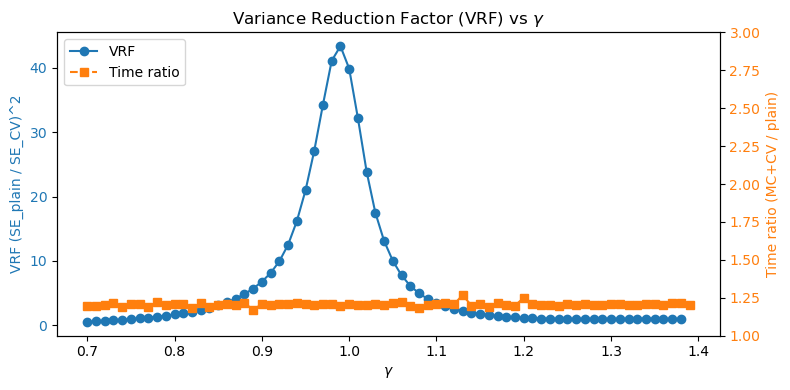

In [11]:

# Expect df from the previous cell (numeric VRF and optional Time_ratio)
if 'df' not in globals():
    raise RuntimeError('DataFrame `df` not found in notebook scope. Run the summary table cell first.')
# intercept Axes.set_xticks to limit number of tick positions (avoid overcrowding)

# keep full data for plotting
x = df['gamma']
y_vrf = df['VRF']
y_vrf = df['VRF']
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(x, y_vrf, marker='o', color='C0', label='VRF')
ax1.set_xlabel('$\gamma$')
ax1.set_ylabel('VRF (SE_plain / SE_CV)^2', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# secondary axis for time ratio if present
if 'Time_ratio' in df.columns:
    ax2 = ax1.twinx()
    ax2.plot(x, df['Time_ratio'], marker='s', linestyle='--', color='C1', label='Time ratio')
    ax2.set_ylabel('Time ratio (MC+CV / plain)', color='C1')
    ax2.set_ylim(1,3)
    ax2.tick_params(axis='y', labelcolor='C1')
# title and legend
plt.title('Variance Reduction Factor (VRF) vs $\gamma$')
# combine legends if both axes used
lines, labels = ax1.get_legend_handles_labels()
if 'ax2' in locals():
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines += lines2; labels += labels2
    ax1.legend(lines, labels, loc='upper left')
else:
    ax1.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'VRF_vs_gammaQMC.png'), dpi=150)
plt.show()



         N  se_plain     se_cv       vrf  time_plain     time_cv  time_ratio
0      128  0.253900  0.152596  2.768468    0.166560    1.472901    8.843059
1      256  0.197098  0.097408  4.094271    0.182108    1.478701    8.119898
2      512  0.100549  0.060054  2.803298    0.217840    1.516299    6.960622
3     1024  0.039709  0.034860  1.297562    0.284170    1.582177    5.567716
4     2048  0.022835  0.023447  0.948472    0.414602    1.713346    4.132511
5     4096  0.015052  0.010664  1.992414    0.783107    2.065757    2.637899
6     8192  0.012796  0.008468  2.283277    1.381719    2.729743    1.975613
7    16384  0.013621  0.009795  1.933541    2.506453    3.907602    1.559017
8    32768  0.004093  0.003260  1.576213    5.327717    6.730666    1.263330
9    65536  0.004844  0.005052  0.919290   12.291292   13.906725    1.131429
10  131072  0.002209  0.002464  0.803863   41.057661   41.687793    1.015347
11  262144  0.001453  0.001634  0.790700   95.037767  100.206457    1.054386

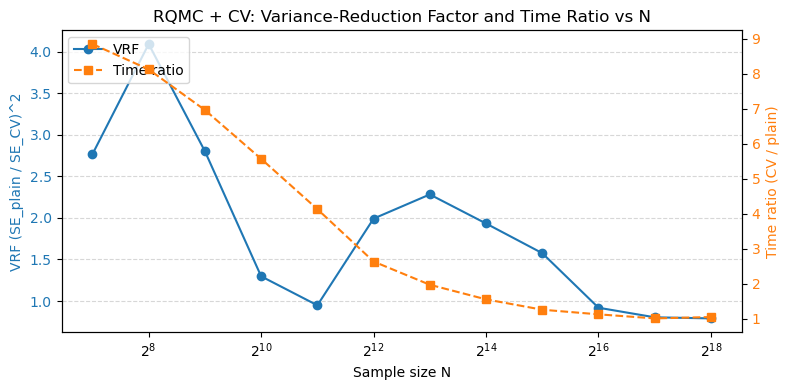

In [12]:
import matplotlib.pyplot as plt
# sample sizes to evaluate
gamma=1.2
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)
Ns = [2**7,2**8,2**9,2**10,2**11, 2**12,2**13, 2**14, 2**15, 2**16, 2**17, 2**18]  # from 128 to 262144
scrambles = batches  # use the same number of scrambles as earlier
rows = []
for Nn in Ns:
    # RQMC without CV
    t0 = time.perf_counter()
    mean_plain, se_plain, ci_plain, var_between_plain = sim.rqmc_with_scrambles(Nn, scrambles, euler=False, CV=False, use_bb=True)
    t_plain = time.perf_counter() - t0
    # RQMC with CV
    t0 = time.perf_counter()
    mean_cv, se_cv, ci_cv, var_between_cv = sim.rqmc_with_scrambles(Nn, scrambles, euler=False, CV=True, use_bb=True)
    t_cv = time.perf_counter() - t0
    vrf = (se_plain / se_cv)**2 if se_cv > 0 else np.nan
    time_ratio = t_cv / t_plain if t_plain > 0 else np.nan
    rows.append({'N': Nn, 'se_plain': se_plain, 'se_cv': se_cv, 'vrf': vrf, 'time_plain': t_plain, 'time_cv': t_cv, 'time_ratio': time_ratio})
df_rq = pd.DataFrame(rows)
print(df_rq)
# Plot VRF (blue) and Time ratio (orange)
from matplotlib.ticker import LogLocator, FuncFormatter

fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(df_rq['N'], df_rq['vrf'], marker='o', color='C0', label='VRF')
ax1.set_xscale('log', base=2)
# use LogLocator/FuncFormatter to avoid tick/label recursion issues and handle log-scale correctly
ax1.xaxis.set_major_locator(LogLocator(base=2.0))
ax1.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f"$2^{{{int(np.round(np.log2(val)))}}}$"))
ax1.set_xlabel('Sample size N')
ax1.set_ylabel('VRF (SE_plain / SE_CV)^2', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
ax2 = ax1.twinx()
ax2.plot(df_rq['N'], df_rq['time_ratio'], marker='s', linestyle='--', color='C1', label='Time ratio')
ax2.set_ylabel('Time ratio (CV / plain)', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
#ax3 = ax1.twinx()
#ax3.plot(df_rq['N'], df_rq['vrf']/df_rq['time_ratio'], marker='o', color='C0', label='VRF')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('RQMC + CV: Variance-Reduction Factor and Time Ratio vs N')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'RQMC_CV_efficiency.png'), dpi=150)
plt.show()

<Figure size 1000x400 with 0 Axes>

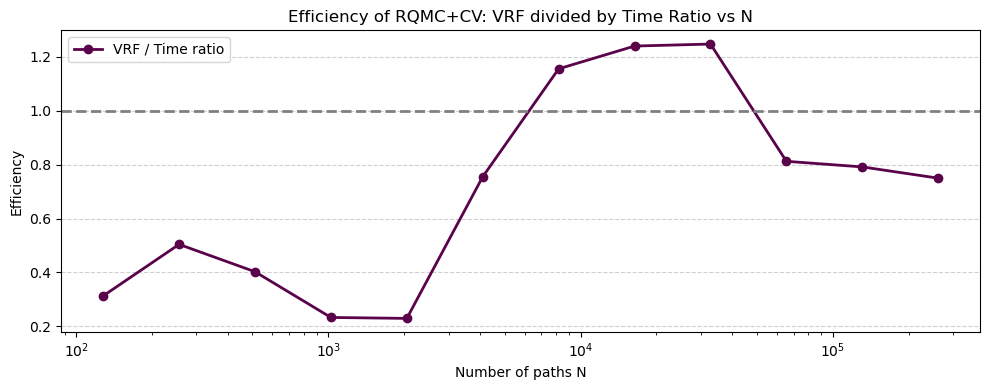

In [13]:
plt.figure(figsize=(10,4))
x = df_rq['N']
y = df_rq['vrf'] / df_rq['time_ratio']

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(x, y, marker='o', color='#5a024a', linewidth=2, markersize=6, label='VRF / Time ratio')
ax.set_xscale('log', base=10)
ax.xaxis.set_major_locator(LogLocator(base=10.0))
ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f"$2^{{{int(np.round(np.log2(val)))}}}$"))
ax.set_xlabel('Number of paths N')
ax.set_ylabel('Efficiency')
ax.set_title('Efficiency of RQMC+CV: VRF divided by Time Ratio vs N')
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=2)  # reference line
# highlight and annotate the best efficiency
#best_idx = int(np.nanargmax(y))
#ax.scatter([x.iloc[best_idx]], [y.iloc[best_idx]], color='C1', s=80, edgecolor='k', zorder=5)
#ax.annotate(f"max={y.iloc[best_idx]:.2f}\nN={int(x.iloc[best_idx])}", 
#            (x.iloc[best_idx], y.iloc[best_idx]),
#            xytext=(0,10), textcoords='offset points', ha='center', fontsize=9)

ax.set_xscale('log', base=10)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'RQMC_CV_efficiency.png'), dpi=150)
plt.show()


In [14]:
x

0        128
1        256
2        512
3       1024
4       2048
5       4096
6       8192
7      16384
8      32768
9      65536
10    131072
11    262144
Name: N, dtype: int64

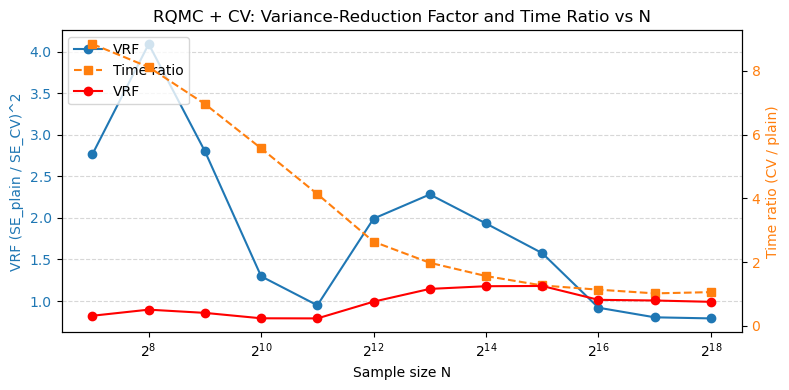

In [15]:
# Plot VRF (blue) and Time ratio (orange)
from matplotlib.ticker import LogLocator, FuncFormatter

fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(df_rq['N'], df_rq['vrf'], marker='o', color='C0', label='VRF')
ax1.set_xscale('log', base=2)
# use LogLocator/FuncFormatter to avoid tick/label recursion issues and handle log-scale correctly
ax1.xaxis.set_major_locator(LogLocator(base=2.0))
ax1.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f"$2^{{{int(np.round(np.log2(val)))}}}$"))
ax1.set_xlabel('Sample size N')
ax1.set_ylabel('VRF (SE_plain / SE_CV)^2', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
ax2 = ax1.twinx()
ax2.plot(df_rq['N'], df_rq['time_ratio'], marker='s', linestyle='--', color='C1', label='Time ratio')
ax2.set_ylabel('Time ratio (CV / plain)', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
#ax3 = ax1.twinx()
ax2.plot(df_rq['N'], df_rq['vrf']/df_rq['time_ratio'], marker='o', color='red', label='VRF')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('RQMC + CV: Variance-Reduction Factor and Time Ratio vs N')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'RQMC_CV_efficiency.png'), dpi=150)
plt.show()

In [16]:
print( df_rq['vrf']/df_rq['time_ratio'])


0     0.313067
1     0.504227
2     0.402737
3     0.233051
4     0.229515
5     0.755303
6     1.155731
7     1.240231
8     1.247665
9     0.812504
10    0.791713
11    0.749915
dtype: float64


### Antithetic 

In [17]:
gamma=1.2
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)

test_cases= range(8,19)# 256 .. 524.288 insert 20
N_values = [2**k for k in test_cases]  
N_values_labels = [f"${2}^{{{k}}}$" for k in  test_cases]
prices_qmc, errors_qmc, cis_qmc, times_qmc = sim.plot_convergence(N_values,method='qmc + bb', batches=batches)
prices_qmc_anti, errors_qmc_anti, cis_qmc_anti, times_qmc_anti = sim.plot_convergence(N_values,method='qmc + bb + antithetic', batches=batches)

# Format CI data
def fmt_ci(ci):
    for i in range(len(ci)):
        low, high = ci[i]
        ci[i] = (float(low), float(high))
    return ci

cis_mc = fmt_ci(cis_mc)
cis_qmc = fmt_ci(cis_qmc)

# Handle CI input for matplotlib errorbar
def ci_to_yerr(prices, cis):
    """Convert CI information to yerr accepted by plt.errorbar."""
    prices = np.asarray(prices, dtype=float)
    cis_arr = np.asarray(cis)
    if cis_arr.ndim == 2 and cis_arr.shape[1] == 2:
        lows = cis_arr[:, 0].astype(float)
        highs = cis_arr[:, 1].astype(float)
        lower_err = prices - lows
        upper_err = highs - prices
    return np.vstack([lower_err, upper_err])
# Build yerr arrays robustly
yerr_mc = ci_to_yerr(np.array(prices_mc), cis_mc)
yerr_qmc = ci_to_yerr(np.array(prices_qmc), cis_qmc)


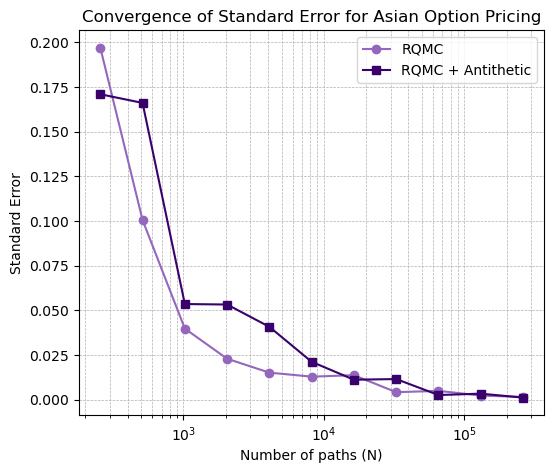

In [18]:
gamma=1.2
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)

test_cases= range(8,19)# 256 .. 524.288 insert 20
N_values = [2**k for k in test_cases]  
N_values_labels = [f"${2}^{{{k}}}$" for k in  test_cases]
prices_qmc, errors_qmc, cis_qmc, times_qmc = sim.plot_convergence(N_values,method='qmc + bb', batches=batches)
prices_qmc_anti, errors_qmc_anti, cis_qmc_anti, times_qmc_anti = sim.plot_convergence(N_values,method='qmc + bb + antithetic', batches=batches)

N_values = [2**k for k in test_cases]
plt.figure(figsize=(6,5))
plt.plot(N_values, errors_qmc, marker='o', label='RQMC', color='#9467bd')
plt.plot(N_values, errors_qmc_anti, marker='s', label='RQMC + Antithetic', color="#38016b")
plt.xscale('log', base=10)
#plt.yscale('log')
#plt.xticks(N_values, N_values_labels)
plt.xlabel('Number of paths (N)')
plt.ylabel('Standard Error')
plt.title('Convergence of Standard Error for Asian Option Pricing')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.savefig(os.path.join(out_dir, 'std_error_convergence_RQMC_anti.png'), dpi=150)
plt.show()

In [19]:
# Create a dataframe comparing CMC vs RQMC across the tested N_values
# Ensure the 'N' array has the same length as the result arrays to avoid ValueError
N_values_labels = [f"${2}^{{{k}}}$" for k in  test_cases]
expected_len = len(prices_qmc)
df_compare = None
# If an existing df_compare already matches the result arrays, reuse it.
# Otherwise, construct a new df_compare using an appropriate N list.
if 'df_compare' in globals() and isinstance(df_compare, pd.DataFrame) and len(df_compare) == expected_len:
    # reuse existing df_compare (assumed to match prices_*/errors_*/times_*)
    pass
else:
    # Determine N_list that matches the length of the result arrays.
    if 'N_values' in globals() and len(N_values) == expected_len:
        N_list = N_values
    else:
        # Fallback: reconstruct a powers-of-two sequence starting at 2**8
        N_list = [2**k for k in range(8, 8 + expected_len)]

    df_compare = pd.DataFrame({
        'N': N_values,
        'Price': np.array(prices_qmc).round(4),
        'SE': np.array(errors_qmc).round(4),
        'Time': np.array(times_qmc).round(4),
        'Price$_{Antithetic}$': np.array(prices_qmc_anti).round(4),
        'SE$_{Antithetic}$': np.array(errors_qmc_anti).round(4),
        'Time$_{Antithetic}$': np.array(times_qmc_anti).round(4),
    })

    # Useful metrics
    #df_compare['se_ratio_mc_to_qmc'] = df_compare['se$_{mc}$'] / df_compare['se$_{qmc}$']  # how many times SE_mc is bigger than SE_qmc
    df_compare['VRF'] = ((df_compare['SE'] / df_compare['SE$_{Antithetic}$'])**2).round(4)  # Variance Reduction Factor
    df_compare['Time ratio'] = (df_compare['Time$_{Antithetic}$'] / df_compare['Time']).round(4)  # how many times time_mc is bigger than time_qmc

# Display and save for later reference
df_compare.drop(columns=['se_ratio_mc_to_qmc'], errors='ignore', inplace=True)
df_display=df_compare[['N', 'Price', 'SE', 'Price$_{Antithetic}$', 'SE$_{Antithetic}$', 'VRF', 'Time ratio']]

latex_path = os.path.join(dir_Tables, 'RQMC_Anti_comparison.tex')
df_display.to_latex(buf=latex_path, index=False, float_format="%.4f")
df_display


,N,Price,SE,Price$_{Antithetic}$,SE$_{Antithetic}$,VRF,Time ratio
0,256,17.5496,0.1971,17.5937,0.1710,1.3286,0.9859
1,512,17.8017,0.1005,17.6380,0.1661,0.3661,0.9914
2,1024,17.8578,0.0397,17.8079,0.0535,0.5506,0.9937
3,2048,17.7704,0.0228,17.8719,0.0532,0.1837,0.9956
4,4096,17.8299,0.0151,17.8579,0.0407,0.1376,0.9915
5,8192,17.8334,0.0128,17.8575,0.0211,0.3680,1.0281
6,16384,17.8367,0.0136,17.8494,0.0111,1.5012,1.0071
7,32768,17.8485,0.0041,17.8452,0.0115,0.1271,1.0049
8,65536,17.8490,0.0048,17.8476,0.0025,3.6864,1.0099
9,131072,17.8468,0.0022,17.8490,0.0033,0.4444,1.0001


In [21]:
prices_qmc_cv, errors_qmc_cv, cis_qmc_cv, times_qmc_cv = sim.plot_convergence(N_values,method='qmc + cv', batches=batches)


In [22]:
prices_qmc_anti_cv, errors_qmc_anti_cv, cis_qmc_anti_cv, times_qmc_anti_cv = sim.plot_convergence(N_values,method='qmc + cv + antithetic', batches=batches)

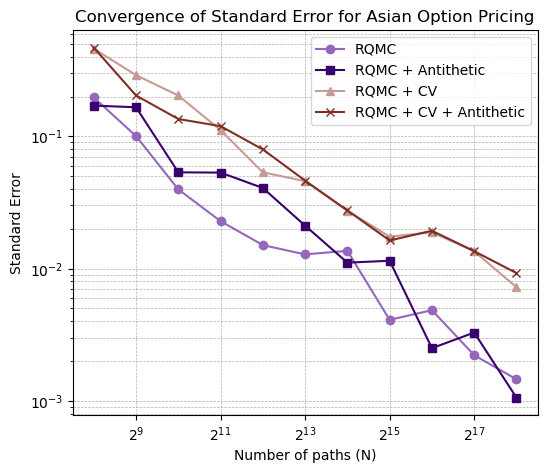

In [23]:
plt.figure(figsize=(6,5))
plt.plot(N_values, errors_qmc, marker='o', label='RQMC', color='#9467bd')
plt.plot(N_values, errors_qmc_anti, marker='s', label='RQMC + Antithetic', color="#38016b")
plt.plot(N_values, errors_qmc_cv, marker='^', label='RQMC + CV', color='#c49c94')
plt.plot(N_values, errors_qmc_anti_cv, marker='x', label='RQMC + CV + Antithetic', color="#7f2f24")
plt.xscale('log', base=2)
plt.yscale('log')
#plt.xticks(N_values, N_values_labels)
plt.xlabel('Number of paths (N)')
plt.ylabel('Standard Error')
plt.title('Convergence of Standard Error for Asian Option Pricing')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.savefig(os.path.join(out_dir, 'std_error_convergence_RQMC_anti.png'), dpi=150)
plt.show()